In [43]:
import json
import itertools
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_eta(vi, wi, theta, V):
    rho_v = theta[vi, :]          # ρ_v = θ_v
    alpha_w = theta[wi + V, :]    # α_w = θ_{V + w}
    eta = rho_v.dot(alpha_w)      # η = ρ_v^T α_w
    return eta

def calculate_p(vi, wi, theta, V):
    eta = calculate_eta(vi, wi, theta, V)
    return sigmoid(eta)

def load_fit(size, save_dir):
    filename = os.path.join(save_dir, f'stan_fit_{size}.pkl')
    with open(filename, 'rb') as f:
        fit = pickle.load(f)
    return fit

def calculate_rmse(theta_samples, true_theta, vocabulary):
    V = len(vocabulary)
    
    p_true = []
    p_avg = []

    for word1 in vocabulary:
        for word2 in vocabulary:
            vi = vocabulary[word1]
            wi = vocabulary[word2]
            p_true.append(calculate_p(vi, wi, true_theta, V))

            p_samples = [calculate_p(vi, wi, theta, V) for theta in theta_samples]
            p_avg.append(np.mean(p_samples))
    
    p_true = np.array(p_true)
    p_avg = np.array(p_avg)
    
    rmse = np.sqrt(np.mean((p_true - p_avg) ** 2))
    return rmse


def extract_word_and_context_vectors_vi2(fit, vocabulary, D=2):
    """
    VI helper: extracts the word and context vectors from the variational parameters.
    """
    variational_samples_pd = fit.variational_params_pd

    # exclude the first three columns (lp__, log_p__, log_g__) and context_vectors_raw
    relevant_params = np.delete(variational_samples_pd, np.s_[3:3+(len(vocabulary)-D)*D], axis=1)
    
    num_samples = relevant_params.shape[0]
    word_vectors = np.zeros((num_samples, len(vocabulary), D))
    context_vectors = np.zeros((num_samples, len(vocabulary), D))
    
    for d in range(D):
        for n in range(len(vocabulary)):
            word_vectors[:, n, d] = relevant_params[:, n + d * len(vocabulary)]
            context_vectors[:, n, d] = relevant_params[:, len(vocabulary) * D + n + d * len(vocabulary)]
    
    return word_vectors, context_vectors


def extract_word_and_context_vectors_vi(samples_pd, vocabulary, D=2):
    """
    VI helper: extracts the word and context vectors from the variational parameters.
    """
    #variational_samples_pd = fit.variational_sample_pd

    # Drop the first three columns: 'lp__', 'log_p__', 'log_g__'
    relevant_params = samples_pd.drop(columns=['lp__','log_p__','log_g__'] , errors='ignore')

    # Drop columns related to 'context_vectors_raw'
    raw_context_columns = [col for col in relevant_params.columns if 'context_vectors_raw' in col]
    relevant_params = relevant_params.drop(columns=raw_context_columns)

    num_samples = relevant_params.shape[0]
    V = len(vocabulary)
    
    word_vectors = np.zeros((num_samples, V, D))
    context_vectors = np.zeros((num_samples, V, D))
    
    for d in range(D):
        for n in range(V):
            word_vectors[:, n, d] = relevant_params[f'word_vectors[{n+1},{d+1}]'].values
            context_vectors[:, n, d] = relevant_params[f'context_vectors[{n+1},{d+1}]'].values
    
    word_vectors = np.transpose(word_vectors, (1, 2, 0))  # dim = (V, D, num_samples)  - reshape to match hmc output.
    context_vectors = np.transpose(context_vectors, (1, 2, 0)) 
    

    return word_vectors, context_vectors

def extract_word_and_context_vectors_gibbs(filepath, vocabulary, D=2):
    df = pd.read_csv(filepath)
    num_samples = df.shape[0]
    V = len(vocabulary)
    
    word_vectors = np.zeros((V, D, num_samples))
    context_vectors = np.zeros((V, D, num_samples))
    
    for n in range(V):
        for d in range(D):
            word_vectors[n, d, :] = df[f'word{n}_{d}'].values
            context_vectors[n, d, :] = df[f'word{n}_c_{d}'].values
    return word_vectors, context_vectors

def credible_interval(samples, confidence=0.90):
    lower_bound = np.percentile(samples, (1 - confidence) / 2 * 100)
    upper_bound = np.percentile(samples, (1 + confidence) / 2 * 100)
    return lower_bound, upper_bound

# Convergence Plots

Size: 100, RMSE: 0.12572098966136888
Size: 200, RMSE: 0.11933171301304289
Size: 500, RMSE: 0.10132137385759758
Size: 1000, RMSE: 0.08863111248403835
Size: 5000, RMSE: 0.058775025405132325
Size: 10000, RMSE: 0.03271509446487707
Size: 20000, RMSE: 0.022812635726706543
Size: 50000, RMSE: 0.013848799579946294
Size: 100000, RMSE: 0.010631243055074886


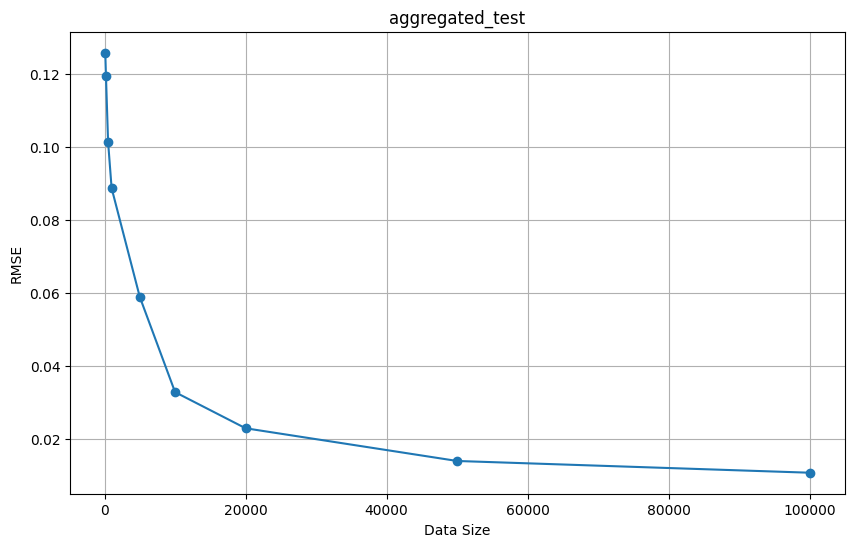

In [14]:

saved_fits_dir = "aggregated_test"#"stan_fits_mfvi_dxd"#"stan_fits_dxdfixmap" "stan_fit_nofix" "stan_fits_frvi_dxd" stan_fits_map
#stan_fits_dxd_mapfit is OUTDATED use instead stan_fits_dxd_mapjacobian :: CORRECTION, turns out they are the same..
# stan_fits_laplacedxd
inference_method = 'hmc'
sizes = [100, 200, 500, 1000, 5000, 10000, 20000, 50000, 100000]

# -- true parameters --
with open('100k_v10_d2_.json') as f:
    data = json.load(f)
true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

rmse_scores = []

for size in sizes:
    if inference_method=='laplace': #just book keeping. Save map fits seperately when doing laplace
        fit = load_fit(f'map_{size}', saved_fits_dir)
    else:
        fit = load_fit(size, saved_fits_dir)

    if inference_method == 'hmc':
        estimated_word_vectors = fit['word_vectors']
        estimated_context_vectors = fit['context_vectors']
        num_samples = estimated_word_vectors.shape[2]
            
    elif inference_method == 'vi':
        #variational_params = fit.variational_sample
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method in ('map', 'laplace'):
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.optimized_params_pd, vocabulary)
        num_samples = 1


    theta_samples = []
    for i in range(num_samples):
        word_vectors = estimated_word_vectors[:, :, i]
        context_vectors = estimated_context_vectors[:, :, i]
        theta = np.vstack((word_vectors, context_vectors))
        theta_samples.append(theta)

        
    rmse = calculate_rmse(theta_samples, true_theta, vocabulary)
    rmse_scores.append(rmse)
    print(f"Size: {size}, RMSE: {rmse}")

# Plot RMSE vs. Size
plt.figure(figsize=(10, 6))
plt.plot(sizes, rmse_scores, marker='o')
plt.xlabel('Data Size')
plt.ylabel('RMSE')
plt.title(f'{saved_fits_dir}')
#plt.xscale('log')
plt.grid(True)
plt.show()


In [121]:
fit.optimized_params_pd[['context_vectors[1,1]', 'context_vectors[1,2]']]

,"context_vectors[1,1]","context_vectors[1,2]"
0,0.067889,-0.057962


In [15]:
rmse_scores

[0.12572098966136888,
 0.11933171301304289,
 0.10132137385759758,
 0.08863111248403835,
 0.058775025405132325,
 0.03271509446487707,
 0.022812635726706543,
 0.013848799579946294,
 0.010631243055074886]

In [12]:
len(rmse_scores)

8

VI
HMC
MAP
Gibbs


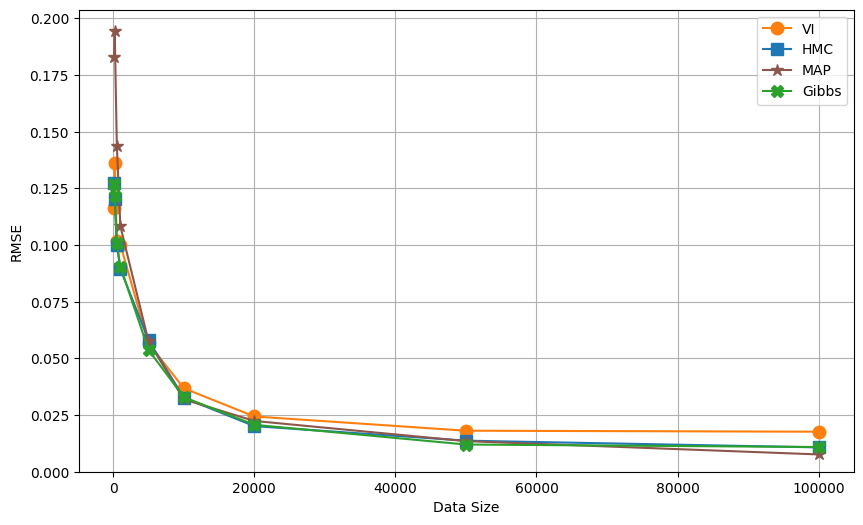

In [24]:
plot_dict = {}

mfvi_dxd = [0.11632057101585079,
 0.13617879109552525,
 0.1018288461556234,
 0.10022146072348655,
 0.05663176971699401,
 0.0368225, 
 0.024384621160304536,
 0.018095653760013868,
 0.017659300187553937]

hmc_dxd = \
[0.12726307352897834,
 0.12033065444990518,
 0.09987843908704594,
 0.08946308659166671,
 0.05796288507616593,
 0.03264020114,
 0.020115503262416252,
 0.013702870051998306,
 0.01074382506784676]

aggregated_hmc = \
[0.12572098966136888,
 0.11933171301304289,
 0.10132137385759758,
 0.08863111248403835,
 0.058775025405132325,
 0.03271509446487707,
 0.022812635726706543,
 0.013848799579946294,
 0.010631243055074886]

map_ = [0.1830949237042245,
 0.19450435084177722,
 0.13259847799247187,
 0.10837218811137438,
 0.0531530555547684,
 0.031893,
 0.01977160486911018,
 0.011878810380597932,
 0.007624994760738237]

map_dxd_outdated = [0.18309383124137898,
 0.19450767181911538,
 0.1326009555370244,
 0.10837730275860734,
 0.05746946626917002,
 0.03571879165622537,
 0.022393612608158923,
 0.01188889922157979,
 0.007610450784667295]

map_dxd = [0.18309419620920864,
 0.19450559919808896,
 0.14390799276624497,
 0.10837988209560422,
 0.057461396240282576,
 0.03190548343639432,
 0.022403710511344162,
 0.013495971230891081,
 0.007627481816835393] #corresponds to the laplace map, which in turn uses dxd fixed params from "original map"


gibbs_dxd = [0.127, 0.1215, 0.101, 0.0905, 0.0537, 0.0329, 0.0207, 0.012, 0.0109]


PLOT_KEYWORD = 'dxdfix' #nofix , dxdfix
plot_dict['VI'] = mfvi_dxd
plot_dict['HMC'] = hmc_dxd
plot_dict['MAP'] = map_dxd
plot_dict['Gibbs'] = gibbs_dxd

colors = {'VI': 'tab:orange', 'HMC': 'tab:blue', 'MAP': 'tab:brown', 'Gibbs': 'tab:green'}
markers = {'VI': 'o', 'HMC': 's', 'MAP': '*', 'Gibbs':'X'}
sizes = [100, 200, 500, 1000, 5000, 10000, 20000, 50000, 100000]


plt.figure(figsize=(10, 6))
for method, rmse in plot_dict.items():
    print(method)
    plt.plot(sizes, rmse, color=colors[method], label=method, marker=markers[method], markersize=9) #, marker='o'

# Plot RMSE vs. Size


plt.xlabel('Data Size')
plt.ylabel('RMSE')
#plt.title(f'{saved_fits_dir}')
#plt.xscale('log')
plt.legend()
#
plt.grid(True)

plt.rcParams.update({'font.size': 14})
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 18

#plt.yscale('log')
#plt.xscale('log')
plt.ylim((0,None))

plt.savefig(f'figs/convergence_{PLOT_KEYWORD}.pdf')
plt.show()


# Word Pair Convergence

colors:
- VI tab:blue
- hmc tab:brown
- laplace tab:orange
- gibbs tab: ?

In [18]:
import pandas as pd

x = pd.read_csv('gibbs-samples/gibbs-samples-N-20000.csv.fix')

x.columns

Index(['word0_0', 'word0_1', 'word0_c_0', 'word0_c_1', 'word1_0', 'word1_1',
       'word1_c_0', 'word1_c_1', 'word2_0', 'word2_1', 'word2_c_0',
       'word2_c_1', 'word3_0', 'word3_1', 'word3_c_0', 'word3_c_1', 'word4_0',
       'word4_1', 'word4_c_0', 'word4_c_1', 'word5_0', 'word5_1', 'word5_c_0',
       'word5_c_1', 'word6_0', 'word6_1', 'word6_c_0', 'word6_c_1', 'word7_0',
       'word7_1', 'word7_c_0', 'word7_c_1', 'word8_0', 'word8_1', 'word8_c_0',
       'word8_c_1', 'word9_0', 'word9_1', 'word9_c_0', 'word9_c_1'],
      dtype='object')

In [44]:
word1 = "word1"
word2 = "word0"

save_fig = False

sizes = [100, 200, 500, 1000, 5000, 20000, 50000, 100000]
saved_fits_dir = "gibbs-samples"#"stan_fits_dxdfixmap" # stan_fits_mfvi_nofix #stan_fit_nofix #stan_fits_laplacedxd #gibbs-samples #stan_fits_mfvi_dxd
inference_method = 'gibbs'


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

true_p = calculate_p(vocabulary[word1], vocabulary[word2], true_theta, len(vocabulary))

p_means = []
credible_intervals = []

for size in sizes:

    if not inference_method == 'gibbs':
        fit = load_fit(size, saved_fits_dir)

    if inference_method == 'hmc':
        estimated_word_vectors = fit['word_vectors']
        estimated_context_vectors = fit['context_vectors']
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'vi':
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method in ('laplace', 'map'):
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.draws_pd(), vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'gibbs':
        filepath = saved_fits_dir + f'/gibbs-samples-N-{size}.csv.fix'
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)
        num_samples = estimated_word_vectors.shape[2]

    theta_samples = []
    for i in range(num_samples):
        word_vectors = estimated_word_vectors[:, :, i]
        context_vectors = estimated_context_vectors[:, :, i]
        theta = np.vstack((word_vectors, context_vectors))
        theta_samples.append(theta)

    vi = vocabulary[word1]
    wi = vocabulary[word2]
    eta_samples = [calculate_p(vi, wi, theta, len(vocabulary)) for theta in theta_samples]

    mean_p = np.mean(eta_samples)
    lower_ci, upper_ci = credible_interval(eta_samples)

    p_means.append(mean_p)
    credible_intervals.append((lower_ci, upper_ci))


p_means = np.array(p_means)
credible_intervals = np.array(credible_intervals)

plt.figure(figsize=(10, 6))
plt.ylim([0.4, 0.8])
plt.plot(sizes, p_means, marker='o', linestyle='-', label='VI', color='tab:green')
plt.fill_between(sizes, credible_intervals[:, 0], credible_intervals[:, 1], color='tab:green', alpha=0.2, label='VI 90% CI')
plt.axhline(y=true_p, color='k', linestyle='--', label='True')
#plt.xlabel('Data Size')
#plt.ylabel('Co-occurrence probability')

#plt.title(f'{saved_fits_dir}: {word1} - {word2}')
#plt.legend()
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlim([0, 100000])

if save_fig:
    plt.savefig(f'figs/wordpair_{saved_fits_dir}_{word1}{word2}.pdf')

plt.show()

AttributeError: 'Series' object has no attribute 'value'

### # Coverage of similarities

In [41]:



sizes = [100, 200, 500, 1000, 5000, 20000, 50000, 100000]
saved_fits_dir = "gibbs-samples"#"aggregated_test"#"stan_fits_dxdfixmap" # stan_fits_mfvi_nofix #stan_fit_nofix #stan_fits_laplacedxd #gibbs-samples #stan_fits_mfvi_dxd
inference_method = 'gibbs'#'hmc'


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

word_pairs = list(itertools.combinations(vocabulary, 2))
total_pairs = len(word_pairs) * 2

coverage_per_size = {}

for size in sizes:
    covered_count = 0
    
    if not inference_method == 'gibbs':
        fit = load_fit(size, saved_fits_dir)

    if inference_method == 'hmc':
        estimated_word_vectors = fit['word_vectors']
        estimated_context_vectors = fit['context_vectors']
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'vi':
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method in ('laplace', 'map'):
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.draws_pd(), vocabulary)
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'gibbs':
        filepath = saved_fits_dir + f'/gibbs-samples-N-{size}.csv.fix'
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)
        num_samples = estimated_word_vectors.shape[2]

    theta_samples = []
    for i in range(num_samples):
        word_vectors = estimated_word_vectors[:, :, i]
        context_vectors = estimated_context_vectors[:, :, i]
        theta = np.vstack((word_vectors, context_vectors))
        theta_samples.append(theta)

    for word1, word2 in word_pairs:
        vi = vocabulary[word1]
        wi = vocabulary[word2]
        true_p = calculate_p(vi, wi, true_theta, len(vocabulary))

        eta_samples = [calculate_p(vi, wi, theta, len(vocabulary)) for theta in theta_samples]
        lower_ci, upper_ci = credible_interval(eta_samples)

        if lower_ci <= true_p <= upper_ci:
            covered_count += 1

        true_p = calculate_p(wi, vi, true_theta, len(vocabulary))

        eta_samples = [calculate_p(wi, vi, theta, len(vocabulary)) for theta in theta_samples]
        lower_ci, upper_ci = credible_interval(eta_samples)

        if lower_ci <= true_p <= upper_ci:
            covered_count += 1

    coverage_percentage = (covered_count / total_pairs) * 100
    coverage_per_size[size] = coverage_percentage


for size, coverage in coverage_per_size.items():
    print(f"data: {size}, coverage: {coverage:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(sizes, [coverage_per_size[size] for size in sizes], marker='o', linestyle='-', color='tab:blue')
plt.xlabel('Data Size')
plt.ylabel('Coverage %')
plt.title(f'Coverage % of true similarity, {saved_fits_dir}')
plt.grid(True)
plt.ylim([0, 100])
#plt.savefig('figs/coverage_all_pairs.pdf')
plt.show()

AttributeError: 'Series' object has no attribute 'value'

In [39]:
x = np.array(list(coverage_per_size.values())).round(1)
x_arrstr = np.char.mod('%.1f', x)
' & '.join(x_arrstr)

'93.3 & 87.8 & 90.0 & 96.7 & 85.6 & 87.8 & 91.1 & 95.6'

# "Donut" Plot

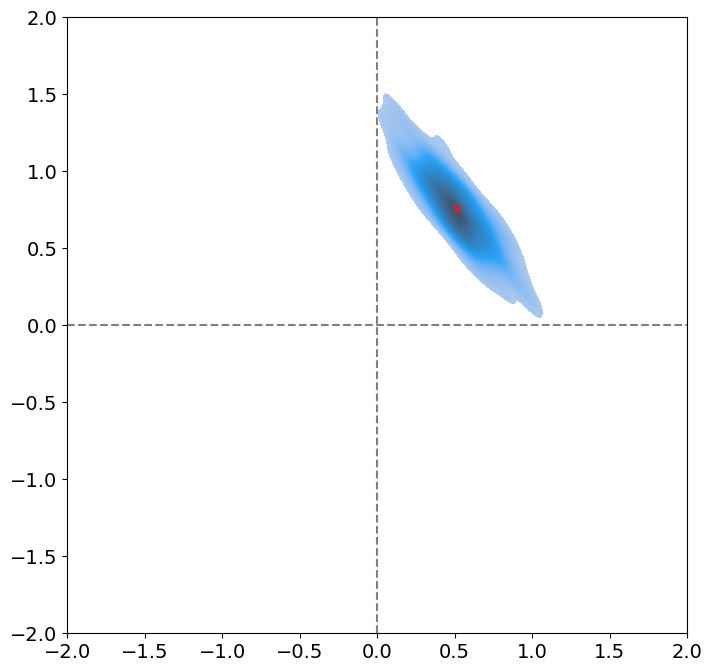

In [7]:
import seaborn as sns
import pandas as pd

word_index = 0

with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# --  specify fit ---
inference_method = 'hmc' 
size = 50000
saved_fits_dir = "stan_fits_dxdfixmap" #"stan_fits_mfvi_dxd" #"stan_fits_dxdfixmap" stan_fit_nofix
fit = load_fit(size, saved_fits_dir)

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit, vocabulary)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 2])
plt.ylim([-2, 2])


plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('')
plt.ylabel('')


plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')

plt.show()



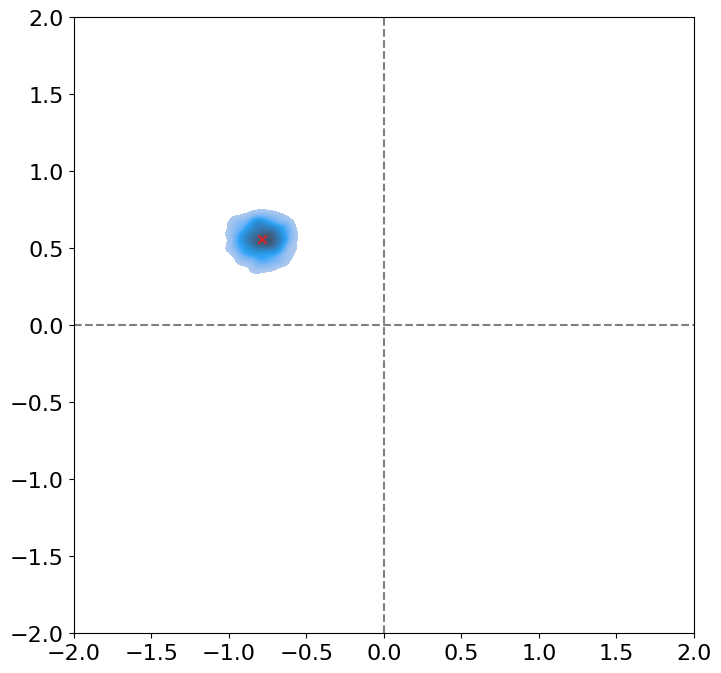

In [143]:
import seaborn as sns
import pandas as pd


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# --  specify fit ---
inference_method = 'vi' 
saved_fits_dir = "stan_fits_mfvi_dxd" #"stan_fits_mfvi_dxd" #"stan_fits_dxdfixmap" #stan_fits_mfvi_nofix
fit = load_fit(size, saved_fits_dir)

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 2])
plt.ylim([-2, 2])


plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('')
plt.ylabel('')


plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')

plt.show()



plt.show()

# Compare Donut

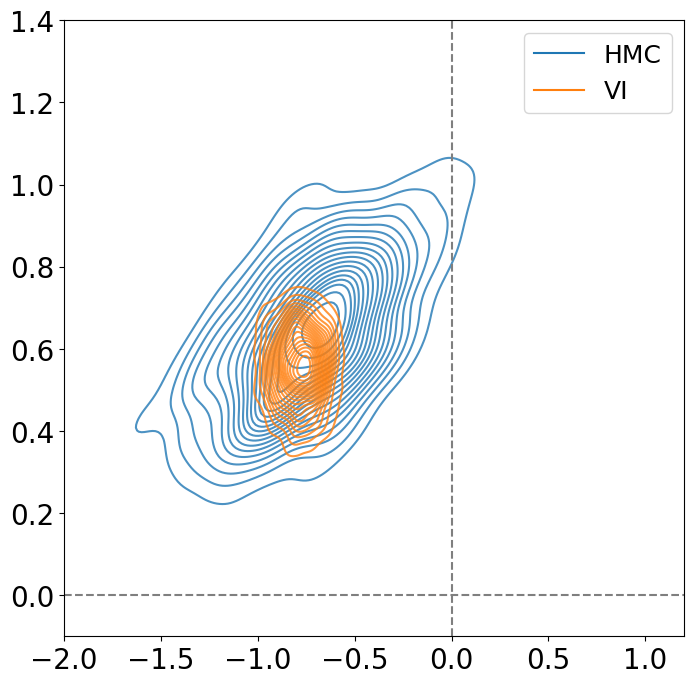

In [144]:
import json
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

word_index = 0

with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# -- specify fit for HMC ---
inference_method_hmc = 'hmc'
size = 20000
saved_fits_dir_hmc = "stan_fits_dxdfixmap"
fit_hmc = load_fit(size, saved_fits_dir_hmc)

word_vectors_samples_hmc = fit_hmc['word_vectors']

# -- specify fit for VI ---
inference_method_vi = 'vi'
saved_fits_dir_vi = "stan_fits_mfvi_dxd"
fit_vi = load_fit(size, saved_fits_dir_vi)

word_vectors_samples_vi, context_vectors_samples_vi = extract_word_and_context_vectors_vi(fit_vi.variational_sample_pd, vocabulary)

# ----

word_samples_hmc = word_vectors_samples_hmc[word_index]
word_samples_vi = word_vectors_samples_vi[word_index]

data_hmc = {
    'Dim 1': word_samples_hmc[0, :],
    'Dim 2': word_samples_hmc[1, :],
    'Method': ['HMC'] * word_samples_hmc.shape[1]
}

data_vi = {
    'Dim 1': word_samples_vi[0, :],
    'Dim 2': word_samples_vi[1, :],
    'Method': ['VI'] * word_samples_vi.shape[1]
}

df_hmc = pd.DataFrame(data_hmc)
df_vi = pd.DataFrame(data_vi)

df_combined = pd.concat([df_hmc, df_vi])

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df_combined[df_combined['Method'] == 'HMC'], fill=False, thresh=0.05, levels=20, alpha=0.8, label='HMC')
sns.kdeplot(x='Dim 1', y='Dim 2', data=df_combined[df_combined['Method'] == 'VI'], fill=False, thresh=0.05, levels=20, alpha=0.8, label='VI')

# legend hack
plt.plot([], [], label='HMC', color='tab:blue')
plt.plot([], [], label='VI', color='tab:orange')

#plt.scatter([np.mean(word_samples_hmc[0, :])], [np.mean(word_samples_hmc[1, :])], marker='x', color='tab:blue', label='Mean HMC')
#plt.scatter([np.mean(word_samples_vi[0, :])], [np.mean(word_samples_vi[1, :])], marker='x', color='tab:orange', label='Mean VI')

plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
#plt.xlim([-2, 2])
#plt.ylim([-2, 2])
plt.xlim([-2, 1.2])
plt.ylim([-0.1, 1.4])

plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlabel('')
plt.ylabel('')

plt.legend()
plt.savefig(f'figs/combined_filled_donut_wordidx{word_index}.pdf')

plt.show()


In [129]:
def extract_word_and_context_vectors_gibbs(filepath, vocabulary, D=2):
    df = pd.read_csv(filepath).iloc[500:]
    print(len(df))
    num_samples = df.shape[0]
    V = len(vocabulary)
    
    word_vectors = np.zeros((V, D, num_samples))
    context_vectors = np.zeros((V, D, num_samples))
    
    for n in range(V):
        for d in range(D):
            word_vectors[n, d, :] = df[f'word{n}_{d}'].values
            context_vectors[n, d, :] = df[f'word{n}_c_{d}'].values
            print(n,d)
    return word_vectors, context_vectors

1496
0 0
0 1
1 0
1 1
2 0
2 1
3 0
3 1
4 0
4 1
5 0
5 1
6 0
6 1
7 0
7 1
8 0
8 1
9 0
9 1


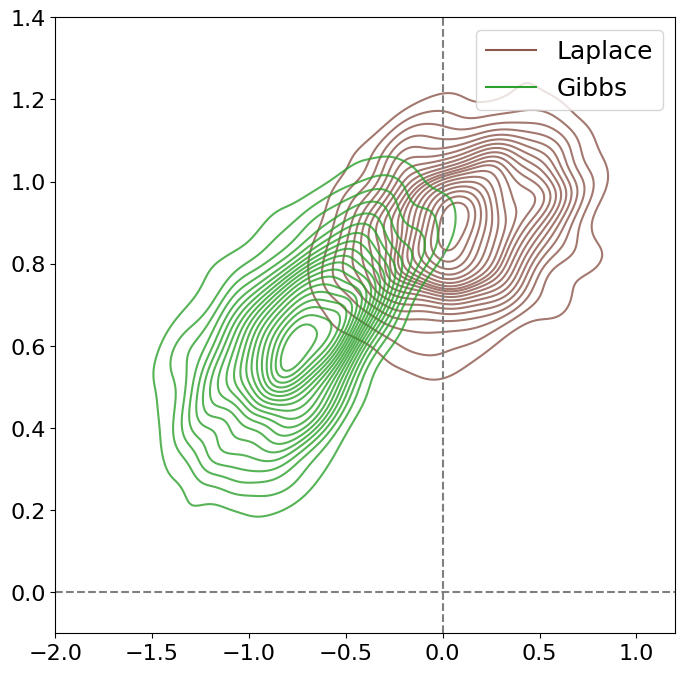

In [141]:

word_index = 0

with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# -- specify fit for Laplace ---
size = 20000
saved_fits_dir_laplace = "stan_fits_laplacedxd"
fit_laplace = load_fit(size, saved_fits_dir_laplace)
word_vectors_samples_laplace, context_vectors_samples_laplace = extract_word_and_context_vectors_vi(fit_laplace.draws_pd(), vocabulary)

# -- specify samples for Gibbs ---
file_path_gibbs = f'gibbs-samples/gibbs-samples-N-{size}.csv.fix'
word_vectors_samples_gibbs, context_vectors_samples_gibbs = extract_word_and_context_vectors_gibbs(file_path_gibbs, vocabulary)

# ----

word_samples_laplace = word_vectors_samples_laplace[word_index]
word_samples_gibbs = word_vectors_samples_gibbs[word_index]

data_laplace = {
    'Dim 1': word_samples_laplace[0, :],
    'Dim 2': word_samples_laplace[1, :],
    'Method': ['Laplace'] * word_samples_laplace.shape[1]
}

data_gibbs = {
    'Dim 1': word_samples_gibbs[0, :],
    'Dim 2': word_samples_gibbs[1, :],
    'Method': ['Gibbs'] * word_samples_gibbs.shape[1]
}

df_laplace = pd.DataFrame(data_laplace)
df_gibbs = pd.DataFrame(data_gibbs)

df_combined = pd.concat([df_laplace, df_gibbs])

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df_combined[df_combined['Method'] == 'Laplace'], fill=False, thresh=0.05, levels=20, alpha=0.8, label='Laplace', color='tab:brown')
sns.kdeplot(x='Dim 1', y='Dim 2', data=df_combined[df_combined['Method'] == 'Gibbs'], fill=False, thresh=0.05, levels=20, alpha=0.8, label='Gibbs', color='tab:green')

plt.plot([], [], label='Laplace', color='tab:brown')
plt.plot([], [], label='Gibbs', color='tab:green')

plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 1.2])
plt.ylim([-0.1, 1.4])

plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('')
plt.ylabel('')

plt.legend()
plt.savefig(f'figs/combined_gibbslaplace_donut_wordidx{word_index}.pdf')

plt.show()


In [132]:
context_vectors_samples_gibbs[0]

array([[ 0.12898   ,  0.12898   ,  0.12898   , ...,  0.12898   ,
         0.12898   ,  0.12898   ],
       [-0.00735445, -0.00735445, -0.00735445, ..., -0.00735445,
        -0.00735445, -0.00735445]])

In [133]:
context_vectors_samples_gibbs[1]

array([[-0.206421, -0.206421, -0.206421, ..., -0.206421, -0.206421,
        -0.206421],
       [ 0.72608 ,  0.72608 ,  0.72608 , ...,  0.72608 ,  0.72608 ,
         0.72608 ]])

In [134]:
context_vectors_samples_laplace[0]

array([[ 0.12898   ,  0.12898   ,  0.12898   , ...,  0.12898   ,
         0.12898   ,  0.12898   ],
       [-0.00735445, -0.00735445, -0.00735445, ..., -0.00735445,
        -0.00735445, -0.00735445]])

In [135]:
context_vectors_samples_laplace[1]

array([[-0.206421, -0.206421, -0.206421, ..., -0.206421, -0.206421,
        -0.206421],
       [ 0.72608 ,  0.72608 ,  0.72608 , ...,  0.72608 ,  0.72608 ,
         0.72608 ]])

In [117]:
context_vectors_samples_vi[0]

array([[-0.0891169 , -0.0891169 , -0.0891169 , ..., -0.0891169 ,
        -0.0891169 , -0.0891169 ],
       [ 0.00580257,  0.00580257,  0.00580257, ...,  0.00580257,
         0.00580257,  0.00580257]])

In [118]:
context_vectors_samples_vi[1]

array([[0.59975 , 0.59975 , 0.59975 , ..., 0.59975 , 0.59975 , 0.59975 ],
       [0.438502, 0.438502, 0.438502, ..., 0.438502, 0.438502, 0.438502]])

In [119]:
fit_hmc['context_vectors']

array([[[-0.0891169 , -0.0891169 , -0.0891169 , ..., -0.0891169 ,
         -0.0891169 , -0.0891169 ],
        [ 0.00580257,  0.00580257,  0.00580257, ...,  0.00580257,
          0.00580257,  0.00580257]],

       [[ 0.59975   ,  0.59975   ,  0.59975   , ...,  0.59975   ,
          0.59975   ,  0.59975   ],
        [ 0.438502  ,  0.438502  ,  0.438502  , ...,  0.438502  ,
          0.438502  ,  0.438502  ]],

       [[-1.23677528, -1.08094361, -1.47047348, ..., -1.15523955,
         -1.37746074, -1.35679914],
        [-0.87666109, -0.83323849, -0.58062153, ..., -0.66714189,
         -0.71281219, -0.51612566]],

       ...,

       [[ 0.27581487,  0.22629895,  0.36181902, ...,  0.32640022,
          0.32722429,  0.15530633],
        [ 0.27406667,  0.30796125,  0.26989939, ...,  0.31319514,
          0.20984545,  0.32809836]],

       [[-0.03715823,  0.02102148, -0.23897108, ..., -0.39455428,
         -0.49580671, -0.01870884],
        [-0.74116477, -0.85997657, -0.85363284, ..., -0.85657